Wykresy z treningu WaveRNN

In [1]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def read_json(filename):
    """
    Convert the standard output saved to filename into a pandas dataframe for analysis.
    """

    with open(filename, "r") as f:
        data = f.read()

    # pandas doesn't read single quotes for json
    data = data.replace("'", '"')

    data = [json.loads(l) for l in data.splitlines()]
    return pd.DataFrame(data)

In [3]:
checkpoint_dir_path = "checkpoints/fine-tuning_50e/results3"
logs_file_path = checkpoint_dir_path + "/metrics_logs.txt"
assert os.path.isfile(logs_file_path)
df = read_json(logs_file_path)

In [10]:
df_train_epochs = df[df["group"] == "train_epoch"].copy()
df_validation = df[df["group"] == "validation"].copy()
df_train_epochs["epoch"] += 1
df_validation["epoch"] += 1

In [5]:
df_validation.head()

,group,epoch,loss,gradient,iteration,time,Learning Rate
49,validation,1,6.119226,NaN,NaN,4.541150,0.000001
99,validation,2,5.389672,NaN,NaN,0.903741,0.000001
149,validation,3,5.373626,NaN,NaN,0.917278,0.000001
199,validation,4,5.803883,NaN,NaN,0.931762,0.000001
249,validation,5,5.570918,NaN,NaN,0.960764,0.000001


In [6]:
df_train_epochs.head()

,group,epoch,loss,gradient,iteration,time,Learning Rate
48,train_epoch,1,6.675332,6.675332,NaN,47.310494,NaN
98,train_epoch,2,6.524906,6.524906,NaN,9.667679,NaN
148,train_epoch,3,6.497563,6.497563,NaN,9.879467,NaN
198,train_epoch,4,6.283773,6.283773,NaN,10.095569,NaN
248,train_epoch,5,6.415879,6.415879,NaN,10.334777,NaN


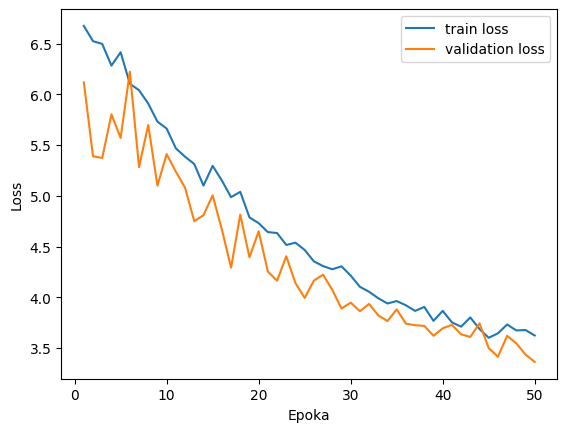

In [7]:
plt.plot(df_train_epochs["epoch"], df_train_epochs["loss"], label="train loss")
plt.plot(df_validation["epoch"], df_validation["loss"], label="validation loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()
plt.show()

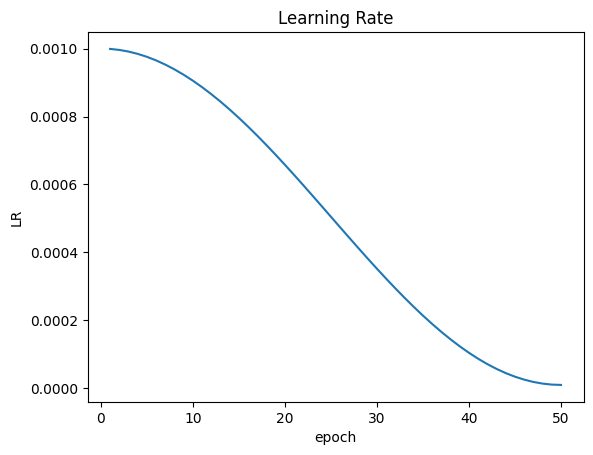

In [30]:
plt.plot(df_validation["epoch"], df_validation["Learning Rate"])
plt.title("Learning Rate")
plt.xlabel("epoch")
plt.ylabel("LR")
plt.show()